<a href="https://colab.research.google.com/github/whateveri/models/blob/ViT/ViT_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Preperation

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report  #count(TP,FP,TN,FN), and generate report
import glob #search specific file path
import random
import warnings
import seaborn as sns #high-level data visualization



def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    #guarantee the reproucibility
    os.environ['PYTHONHASHSEED']=str(seed)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False

seed_everything()
warnings.filterwarnings('ignore')

device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)





cpu


# Load data

In [2]:
import requests
import zipfile
import tarfile
from tqdm import tqdm

URL_Images="https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz"
URL_Anno="https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz"

def download_detaset_from_url(url,save_path=None,dataset_name="petdata"):
    if save_path is None:
        save_path=os.path.join(os.getcwd(),"sample_data",dataset_name)
    os.makedirs(save_path,exist_ok=True)
    filename=os.path.join(save_path,dataset_name)

    #add file extension

    if not any(filename.endswith(ext) for ext in [".zip",".tar.gz"]):
        if url.endswith(".zip"):
            filename+=".zip"
        elif url.endswith(".tar.gz"):
            filename+=".tar.gz"

    #download

    if not os.path.exists(filename):
      print(f'Dowloading dataset from {url} into {filename}....')
      response=requests.get(url,stream=True)

      total_size=int(response.headers.get('content-length',0))
      block_size=1024
      with open(filename,'wb') as file, tqdm(desc=dataset_name,
          total=total_size,
          unit='iB',
          unit_scale=True,
          unit_divisor=1024) as bar:
              for data in response.iter_content(block_size):
                  file.write(data)
                  bar.update(len(data))
    else:
        print(f'File already exist at{filename},skipping download.')

    #extract

    if filename.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(filename,'r') as zip_ref:
            zip_ref.extractall(save_path)

    elif filename.endswith(".tar.gz"):
        print("Extracting tar file...")
        with tarfile.open(filename,'r:gz') as tar_ref:
            tar_ref.extractall(save_path)
    else:
        print("Download Complete. No extraction performed")

download_detaset_from_url(URL_Images,dataset_name="petImage")
download_detaset_from_url(URL_Anno,dataset_name="petAnno")





Dowloading dataset from https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz into /content/sample_data/petImage/petImage.tar.gz....


petImage: 100%|██████████| 755M/755M [00:28<00:00, 27.8MiB/s]


Extracting tar file...
Dowloading dataset from https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz into /content/sample_data/petAnno/petAnno.tar.gz....


petAnno: 100%|██████████| 18.3M/18.3M [00:01<00:00, 13.9MiB/s]


Extracting tar file...


In [3]:
from sklearn.model_selection import train_test_split

img_size=224
batch_size=16


image_path=os.path.join(os.getcwd(),"sample_data","petImage","images")

all_images=glob.glob(os.path.join(image_path,"*.jpg"))

labels=[os.path.basename(p).split("_")[0] for p in all_images]
label_to_idx={label: idx for idx, label in enumerate(sorted(set(labels)))}

n_classes=len(label_to_idx)

df=pd.DataFrame({
    "image_path":all_images,
    "label_str": labels,
})

df["label"]=df["label_str"].map(label_to_idx)

#devide train_data and test_data

df_train,df_temp=train_test_split(df,test_size=0.3,stratify=df["label"],random_state=42)

df_val,df_test=train_test_split(df_temp,test_size=0.5,stratify=df_temp["label"],random_state=42)

print(f'class num:{n_classes}')
print(f'train data num:{len(df_train)}')
print(f'val data num:{len(df_val)}')
print(f'test data num:{len(df_test)}')





class num:35
train data num:5173
val data num:1108
test data num:1109


In [4]:
  from PIL import Image
  from torch.utils.data import Dataset,DataLoader
  class PetData(Dataset):
      def __init__(self,dataframe,transform=None):
          self.df=dataframe.reset_index(drop=True)
          self.transform=transform

      def __len__(self):
          return len(self.df)

      def __getitem__(self,idx):
          image_path=self.df.loc[idx,"image_path"]
          label=int(self.df.loc[idx,"label"])
          image=Image.open(image_path).convert("RGB")

          if self.transform:
              image=self.transform(image)
          return image,label

In [5]:
from torchvision import transforms
import torchvision.transforms.functional as TF
class DataAugment:
    def __call__(self, img):

        #Alway flip

        img=TF.hflip(img) if random.random()< 0.5 else img
        img=TF.vflip(img) if random.random()< 0.5 else img

        #25% probabilty transpose
        if(random.random()>0.75):
            img=img.transpose(Image.TRANSPOSE)

        p= random.random()

        if p > 0.75:
            img=TF.rotate(img,270)
        elif p > 0.5:
            img=TF.rotate(img,180)
        elif p>0.25:
            img=TF.rotate(img,90)

        return img

In [6]:


train_transforms=transforms.Compose([transforms.Resize((img_size,img_size)),
                            DataAugment(),
                            transforms.ToTensor(),
                            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

val_transforms=transforms.Compose([transforms.Resize((img_size,img_size)),
                            transforms.ToTensor(),
                            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

train_dataset=PetData(df_train,transform=train_transforms)

val_dataset=PetData(df_val,transform=val_transforms)

test_dataset=PetData(df_test,transform=val_transforms)

train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True,num_workers=2)

val_loader=DataLoader(val_dataset,batch_size=batch_size,shuffle=False,num_workers=2)

test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=False)



In [7]:
idx_to_label={v:k for k,v in label_to_idx.items()}

print(idx_to_label)
n_classes=len(idx_to_label)
image,label=train_dataset[0]
print(type(image),image.shape)
print(type(label),label)


{0: 'Abyssinian', 1: 'Bengal', 2: 'Birman', 3: 'Bombay', 4: 'British', 5: 'Egyptian', 6: 'Maine', 7: 'Persian', 8: 'Ragdoll', 9: 'Russian', 10: 'Siamese', 11: 'Sphynx', 12: 'american', 13: 'basset', 14: 'beagle', 15: 'boxer', 16: 'chihuahua', 17: 'english', 18: 'german', 19: 'great', 20: 'havanese', 21: 'japanese', 22: 'keeshond', 23: 'leonberger', 24: 'miniature', 25: 'newfoundland', 26: 'pomeranian', 27: 'pug', 28: 'saint', 29: 'samoyed', 30: 'scottish', 31: 'shiba', 32: 'staffordshire', 33: 'wheaten', 34: 'yorkshire'}
<class 'torch.Tensor'> torch.Size([3, 224, 224])
<class 'int'> 21


# Simple data visualizatioin

torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])
torch.Size([3, 224, 224])


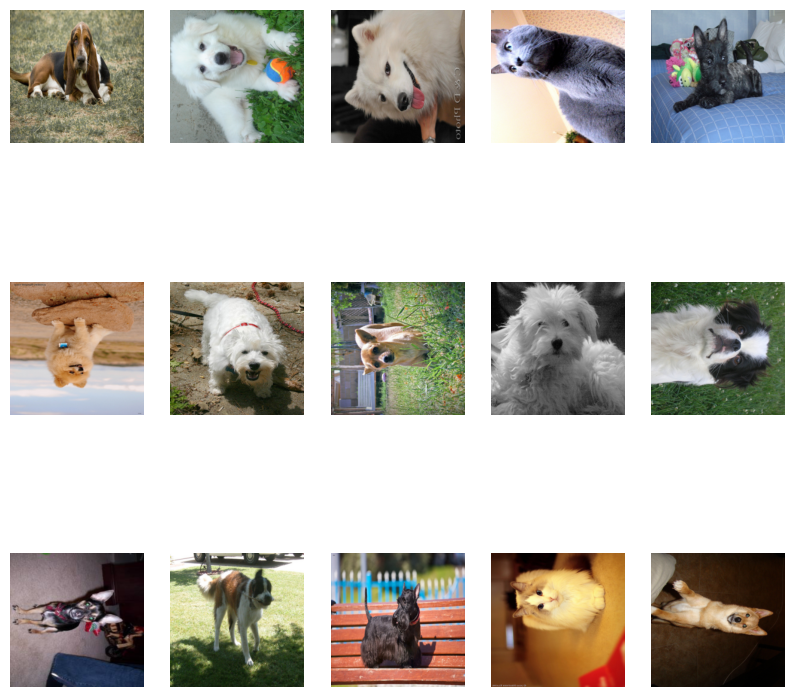

In [14]:
vimages,vlabels=next(iter(train_loader))

fig,ax=plt.subplots(nrows=3,ncols=5,figsize=(10,10))
ax=ax.flatten()

for idx in range(min(15,len(vimages))):
    vimg=vimages[idx]
    print(vimg.shape)
    vimg=vimg.permute(1,2,0).numpy()
    vimg=(vimg*0.5)+0.5
    ax[idx].imshow(vimg)
    ax[idx].axis('off')
plt.show()


# Model Hyperparameters


In [ ]:
learning_rate=0.001
weight_decay=0.0001

num_epoch=5

patch_size=7
#num_patches=(img_size//patch_size)**2
embed_dim=64
num_heads=4 #projection_num % num_head ==0

# Build Model

In [ ]:
#devide images into patches, project to embedding
class PatchEmbed(nn.Module):
    def __init__(self, img_size=img_size,patch_size=patch_size,in_chans=3,embed_dim=embed_dim):
        super().__init__()
        self.grid_size=img_size // patch_size
        self.path_num= self.grid_size * self.grid_size
        self.proj=nn.Conv2d(in_channels=in_chans,out_channels=embed_dim,kernel_size=patch_size,stride=patch_size,device=device)

    def forward(self,x):
    # x: [B, 3, H, W] -> [B, embed_dim, grid, grid] -> [B, num_patches, embed_dim]
        x=self.proj(x)
        x=x.flatten(2)
        x=x.transpose(1,2)
        return x



In [ ]:
#MLP layer
class MLP(nn.Module):
    def __init__(self,in_features,hidden_features=None,out_features=None,p=0.):
        super().__init__()
        if out_features is not None:
            self.out_features=out_features
        else:
            self.out_features=in_features

        if hidden_features is not None:
            self.hidden_features=hidden_features
        else:
            self.hidden_features=in_features

        self.layer1=nn.Linear(in_features=in_features,out_features=hidden_features,device=device)

        self.layer2=nn.Linear(in_features=hidden_features,out_features=out_features,device=device)

        self.gelu=nn.GELU()
        self.dropout=nn.Dropout(p=p)

    def forward(self,x):
        x=self.layer1(x)
        x=self.gelu(x)
        x=self.dropout(x)

        x=self.layer2(x)
        x=self.dropout(x)

        return x


In [ ]:
#Attention Layer

class Attention(nn.Module):
    def __init__(self,embed_dim,num_heads=num_heads,qkv_biads=True,attn_drop=0.,proj_drop=0. ):
        super().__init__()
        self.num_heads=num_heads
        head_dim= embed_dim // self.num_heads
        self.scale= head_dim ** -0.5
        self.qkv=nn.Linear(in_features=embed_dim,out_features=embed_dim*3,bias=qkv_biads,device=device)
        self.attn_dropout=nn.Dropout(p=attn_drop)
        self.proj_dripout=nn.Dropout(p=proj_drop)
        self.proj=nn.Linear(in_features=embed_dim,out_features=embed_dim,device=device)
        self.attn=nn.Softmax(-1)

    def forward(self,x):
        B,N,C=x.shape  #Batch,Num_batch, Embed_dim
        qkv=self.qkv(x)  #B,N,C*3
        qkv=qkv.reshape(B,N,3,self.num_heads,C// self.num_heads) #B,N,3,k,Dh
        qkv=qkv.permute(2,0,3,1,4) # 3,B,k,N,Dh
        q,k,v=qkv[0],qkv[1],qkv[2] #each: B,k,N,Dh
        attn=torch.matmul(q,k.transpose(-2,-1))* self.scale
        attn=self.attn(attn)
        attn=self.attn_dropout(attn) # B,k,N,N

        out=torch.matmul(attn,v) # B,k,N,Dh
        out=out.transpose(1,2) #B,N,k,Dh
        out=out.reshape(B,N,C)  #B,N,k*Dh
        # merge k-head attention
        out=self.proj(out)  #B,N,C
        out=self.proj_dripout(out)
        return out



In [ ]:
# Transformer Encoder block
class block(nn.Module):
    def __init__(self,embed_dim=embed_dim,num_heads=num_heads,mlp_ratio=4.,qkv_biads=True,p=0., attn_drop=0.):
        super().__init__()
        self.attn=Attention(embed_dim=embed_dim,num_heads=num_heads,qkv_biads=qkv_biads,attn_drop=attn_drop,proj_drop=p)

        self.mlp=MLP(in_features=embed_dim,out_features=int(embed_dim*mlp_ratio),p=p)

        self.ln1=nn.LayerNorm(embed_dim,device=device)
        self.ln2=nn.LayerNorm(embed_dim,device=device)

    def forward(self,x):
        res=x
        x=self.ln1(x)
        x=self.attn(x)
        res=res+x

        x=self.ln2(res)
        x=self.mlp(x)
        out=res+x

        return out

In [ ]:
# ViT model
class ViT(nn.Module):
    def __init__(self,embed_dim=embed_dim,img_size=img_size, num_classes=n_classes,
    depth=8,
    n_channels=3,
    num_heads=num_heads,
    mlp_ratio=4.,
    qkv_bias=True,
    p=0,
    attn_p=0.,
    block=block):
        super().__init__()
        self.patch_embed=PatchEmbed()
        num_patches=self.patch_embed.path_num
        self.pos_embed=nn.Parameter(torch.zeros(1,num_patches,embed_dim))
        self.pos_drop=nn.Dropout(p=p)
        self.blocks=nn.Sequential(*[
            block() for _ in range(depth)
        ])
        self.norm=nn.LayerNorm(embed_dim)
        self.head=nn.Linear(in_features=embed_dim,out_features=n_classes,device=device)

        nn.init.trunc_normal_(self.pos_embed,std=0.02)

    def forward(self,x):
        embeded_patches=self.patch_embed(x)
        posed_patches=embeded_patches+self.pos_embed
        x=self.pos_drop(posed_patches)
        x=self.blocks(x)
        x=self.norm(x)

        pooled=x.mean(dim=1) # B,embed_dim
        return self.head(pooled) #B,n_classes

